# NLI Fine-Tuning Assignment

This notebook runs all 5 tasks:
- **Task 1:** Baseline Full Fine-Tuning
- **Task 2:** Hyperparameter Sensitivity Study
- **Task 3:** Parameter-Efficient Fine-Tuning (PEFT)
- **Task 4:** Cross-Dataset Generalisation
- **Task 5:** Data Efficiency Analysis

**Hardware:** GPU required (Colab T4 is sufficient)  
**Runtime:** ~30–60 minutes on a T4 GPU with default settings

## 0. Setup

### 0.1 Install Dependencies

In [ ]:
!pip install -q transformers datasets torch scikit-learn matplotlib seaborn peft accelerate

### 0.2 Imports and Configuration

In [ ]:
import os
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
)

warnings.filterwarnings("ignore")

# ═══════════════════════════════════════════════════════════
#  SPEED CONFIGURATION — Adjust these to trade speed vs thoroughness
# ═══════════════════════════════════════════════════════════
MODEL_NAME     = "distilbert-base-uncased"
MAX_LENGTH     = 128
SEED           = 42

# Fraction of SNLI training data to use (1.0 = full dataset ~550K)
# Use 0.1 for fast runs (~55K), 0.25 for moderate (~137K), 1.0 for full
TRAIN_FRACTION = 0.1

# Max eval/test examples (None = use all)
MAX_EVAL_EXAMPLES = 5000
MAX_TEST_EXAMPLES = 5000

# Training defaults
DEFAULT_EPOCHS     = 3
DEFAULT_LR         = 2e-5
DEFAULT_BATCH_SIZE = 32

# Enable mixed precision (much faster on GPU, set False for CPU)
USE_FP16 = torch.cuda.is_available()

# ═══════════════════════════════════════════════════════════

MODEL_DIR = Path("./models")
MODEL_DIR.mkdir(exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"Train fraction: {TRAIN_FRACTION:.0%}")
print(f"FP16: {USE_FP16}")

LABEL_NAMES = ["entailment", "neutral", "contradiction"]

Device: cuda
Train fraction: 10%
FP16: True


### 0.3 Helper Functions

In [ ]:
def set_seed(seed=SEED):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_fresh_model(model_name=MODEL_NAME, num_labels=3):
    """Always load a fresh model from pre-trained weights."""
    set_seed()
    return AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=num_labels
    )


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds)}


def get_predictions(trainer, dataset):
    output = trainer.predict(dataset)
    preds = np.argmax(output.predictions, axis=-1)
    return preds, output.label_ids


def make_training_args(output_dir, lr=DEFAULT_LR, batch_size=DEFAULT_BATCH_SIZE,
                       epochs=DEFAULT_EPOCHS, **kwargs):
    """Create TrainingArguments with speed optimizations baked in."""
    return TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=128,
        num_train_epochs=epochs,
        warmup_ratio=0.06,
        weight_decay=0.01,
        logging_steps=100,
        fp16=USE_FP16,
        dataloader_num_workers=2,
        report_to="none",
        seed=SEED,
        **kwargs,
    )


def cleanup():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

### 0.4 Load, Subsample, and Tokenize SNLI

In [ ]:
# Load and filter
dataset = load_dataset("snli")
dataset = dataset.filter(lambda x: x["label"] != -1)
print(f"Full dataset — Train: {len(dataset['train']):,}  "
      f"Val: {len(dataset['validation']):,}  Test: {len(dataset['test']):,}")

# Subsample for speed
set_seed()
train_n = int(len(dataset["train"]) * TRAIN_FRACTION)
train_subset = dataset["train"].shuffle(seed=SEED).select(range(train_n))

val_data = dataset["validation"]
if MAX_EVAL_EXAMPLES and len(val_data) > MAX_EVAL_EXAMPLES:
    val_data = val_data.shuffle(seed=SEED).select(range(MAX_EVAL_EXAMPLES))

test_data = dataset["test"]
if MAX_TEST_EXAMPLES and len(test_data) > MAX_TEST_EXAMPLES:
    test_data = test_data.shuffle(seed=SEED).select(range(MAX_TEST_EXAMPLES))

print(f"\nUsing — Train: {len(train_subset):,}  Val: {len(val_data):,}  Test: {len(test_data):,}")

README.md: 0.00B [00:00, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/412k [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/413k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/19.6M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

...

Generating train split:   0%|          | 0/550152 [00:00<?, ? examples/s]

Filter:   0%|          | 0/10000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/10000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/550152 [00:00<?, ? examples/s]

Full dataset — Train: 549,367  Val: 9,842  Test: 9,824

Using — Train: 54,936  Val: 5,000  Test: 5,000


In [ ]:
# Tokenize
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(
        batch["premise"], batch["hypothesis"],
        truncation=True, max_length=MAX_LENGTH, padding="max_length",
    )

train_tok = train_subset.map(tokenize_fn, batched=True, num_proc=2)
val_tok   = val_data.map(tokenize_fn, batched=True, num_proc=2)
test_tok  = test_data.map(tokenize_fn, batched=True, num_proc=2)
print("Tokenization complete.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map (num_proc=2):   0%|          | 0/54936 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/5000 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/5000 [00:00<?, ? examples/s]

Tokenization complete.


---
## Task 1: Baseline Full Fine-Tuning

**Goal:** Fine-tune a pre-trained model on SNLI to establish a baseline.

### 1(a) Perform Task

In [ ]:
# Load fresh model
set_seed()
model = get_fresh_model()

# Training arguments
args = TrainingArguments(
    output_dir="./results/task1",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    warmup_ratio=0.06,
    weight_decay=0.01,
    logging_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
)

print("Training baseline model...")
start = time.time()
trainer.train()
train_time = time.time() - start
print(f"\nTraining completed in {train_time / 60:.1f} minutes")

# Save model for later tasks
trainer.save_model(str(MODEL_DIR / "task1_baseline"))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training baseline model...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.547983,0.480029,0.809400
2,0.423633,0.445399,0.834600
3,0.343238,0.466033,0.833400


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Training completed in 28.8 minutes


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### 1(b) Analysis and Plots

Running evaluation on test set...


Test Accuracy: 0.8280



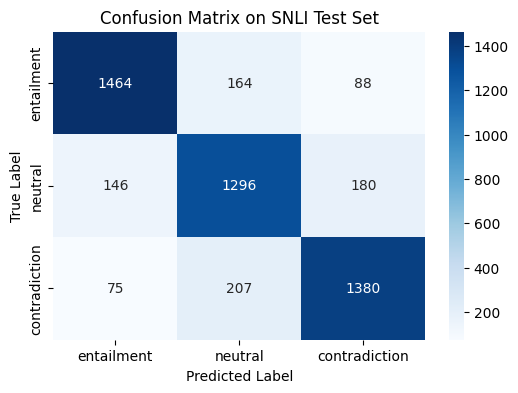

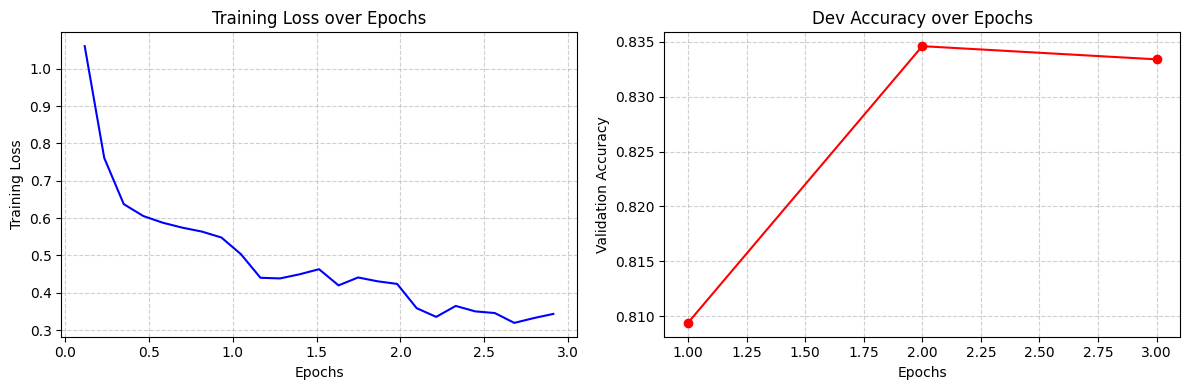


Classification Report (Per-class metrics):
               precision    recall  f1-score   support

   entailment       0.87      0.85      0.86      1716
      neutral       0.78      0.80      0.79      1622
contradiction       0.84      0.83      0.83      1662

     accuracy                           0.83      5000
    macro avg       0.83      0.83      0.83      5000
 weighted avg       0.83      0.83      0.83      5000



In [ ]:
print("Running evaluation on test set...")
preds_test, labels_test = get_predictions(trainer, test_tok)
test_acc = accuracy_score(labels_test, preds_test)
print(f"Test Accuracy: {test_acc:.4f}\n")

cm = confusion_matrix(labels_test, preds_test)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on SNLI Test Set')
plt.show()

log_history = trainer.state.log_history
# extract loss and accuracy steps
train_loss = [x['loss'] for x in log_history if 'loss' in x]
train_epochs = [x['epoch'] for x in log_history if 'loss' in x]

eval_acc = [x['eval_accuracy'] for x in log_history if 'eval_accuracy' in x]
eval_epochs = [x['epoch'] for x in log_history if 'eval_accuracy' in x]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# training Loss
axes[0].plot(train_epochs, train_loss, 'b-', label='Training Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss over Epochs')
axes[0].grid(True, linestyle='--', alpha=0.6)

# dev Accuracy
axes[1].plot(eval_epochs, eval_acc, 'r-', marker='o', label='Dev Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Dev Accuracy over Epochs')
axes[1].grid(True, linestyle='--', alpha=0.6)

fig.tight_layout()
plt.show()

print("\nClassification Report (Per-class metrics):")
print(classification_report(labels_test, preds_test, target_names=LABEL_NAMES))

### 1(c) Comparative Study

### 1(d) Possible Reasons Behind Observations

---
## Task 2: Hyperparameter Sensitivity Study

**Goal:** Understand how key hyperparameters affect fine-tuning performance.

### 2(a) Perform Task

In [ ]:
results = []

# --- 1. Learning Rate Sweep ---
learning_rates = [1e-5, 2e-5, 5e-5, 1e-4]
for lr in learning_rates:
    print(f"Testing Learning Rate: {lr}")
    model = get_fresh_model()
    args = make_training_args(f"./results/task2/lr_{lr}", lr=lr)

    trainer = Trainer(model=model, args=args, train_dataset=train_tok, eval_dataset=val_tok, compute_metrics=compute_metrics)
    trainer.train()
    metrics = trainer.evaluate()
    results.append({"hp": "lr", "val": lr, "acc": metrics["eval_accuracy"]})

Testing Learning Rate: 1e-05


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.574494,0.513040,0.799600
2,0.495072,0.475182,0.817000
3,0.447737,0.473766,0.820000


Testing Learning Rate: 2e-05


...

Epoch,Training Loss,Validation Loss,Accuracy
1,0.518070,0.441807,0.824800
2,0.362198,0.444755,0.838600
3,0.240644,0.529707,0.834400


Testing Learning Rate: 0.0001


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.531981,0.456017,0.819800
2,0.366883,0.445119,0.832600
3,0.211935,0.554420,0.833600


In [ ]:
# --- 2. Batch Size Sweep ---
batch_sizes = [16, 32, 64]
for bs in batch_sizes:
    print(f"Testing Batch Size: {bs}")
    model = get_fresh_model()
    args = make_training_args(f"./results/task2/bs_{bs}", batch_size=bs)

    trainer = Trainer(model=model, args=args, train_dataset=train_tok, eval_dataset=val_tok, compute_metrics=compute_metrics)
    trainer.train()
    metrics = trainer.evaluate()
    results.append({"hp": "bs", "val": bs, "acc": metrics["eval_accuracy"]})

Testing Batch Size: 16


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.537120,0.459778,0.823400
2,0.394971,0.443051,0.840400
3,0.274121,0.502271,0.839000


Testing Batch Size: 32


...

Epoch,Training Loss,Validation Loss,Accuracy
1,0.537056,0.482484,0.810200
2,0.437645,0.449632,0.828800
3,0.348080,0.470799,0.833200


Testing Batch Size: 64


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.566816,0.497905,0.807000
2,0.455237,0.454927,0.824600
3,0.388334,0.458667,0.829200


In [ ]:
# --- 3. Epochs Sweep ---
epochs_list = [1, 2, 3, 5]
for ep in epochs_list:
    print(f"Testing Epochs: {ep}")
    model = get_fresh_model()
    args = make_training_args(f"./results/task2/ep_{ep}", epochs=ep)

    trainer = Trainer(model=model, args=args, train_dataset=train_tok, eval_dataset=val_tok, compute_metrics=compute_metrics)
    trainer.train()
    metrics = trainer.evaluate()
    results.append({"hp": "ep", "val": ep, "acc": metrics["eval_accuracy"]})

Testing Epochs: 1


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.548664,0.484265,0.814400


Testing Epochs: 2


...

Epoch,Training Loss,Validation Loss,Accuracy
1,0.537056,0.482484,0.810200
2,0.437645,0.449632,0.828800
3,0.348080,0.470799,0.833200


Testing Epochs: 5


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.543151,0.485952,0.805200
2,0.444300,0.446120,0.829600
3,0.344739,0.483730,0.829400
4,0.249305,0.528857,0.834400
5,0.208536,0.567340,0.832000


### 2(b) Analysis and Plots

,hp,val,acc
0,lr,0.00001,0.8200
1,lr,0.00002,0.8332
2,lr,0.00005,0.8344
3,lr,0.00010,0.8336
4,bs,16.00000,0.8390
5,bs,32.00000,0.8332
6,bs,64.00000,0.8292
7,ep,1.00000,0.8144
8,ep,2.00000,0.8326
9,ep,3.00000,0.8332


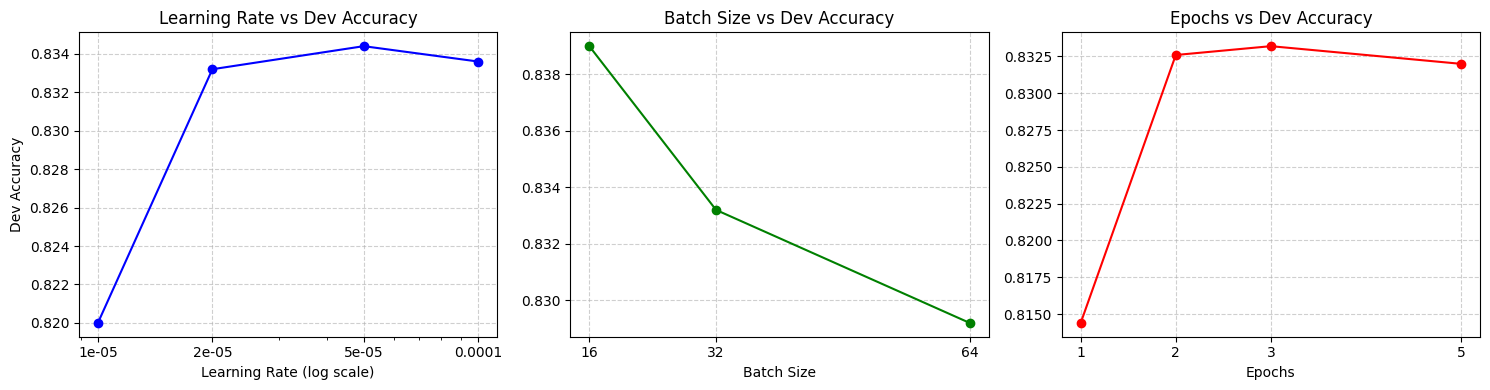

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results)
display(results_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# learning rate plot
lr_data = results_df[results_df["hp"] == "lr"]
axes[0].plot(lr_data["val"], lr_data["acc"], marker='o', color='blue')
axes[0].set_xscale('log') # Log scale as requested
axes[0].set_title("Learning Rate vs Dev Accuracy")
axes[0].set_xlabel("Learning Rate (log scale)")
axes[0].set_xticks(learning_rates)
axes[0].set_xticklabels([str(lr) for lr in learning_rates])
axes[0].set_ylabel("Dev Accuracy")
axes[0].grid(True, linestyle='--', alpha=0.6)

# batch size plot
bs_data = results_df[results_df["hp"] == "bs"]
axes[1].plot(bs_data["val"], bs_data["acc"], marker='o', color='green')
axes[1].set_title("Batch Size vs Dev Accuracy")
axes[1].set_xlabel("Batch Size")
axes[1].set_xticks(batch_sizes)
axes[1].grid(True, linestyle='--', alpha=0.6)

# epochs plot
ep_data = results_df[results_df["hp"] == "ep"]
axes[2].plot(ep_data["val"], ep_data["acc"], marker='o', color='red')
axes[2].set_title("Epochs vs Dev Accuracy")
axes[2].set_xlabel("Epochs")
axes[2].set_xticks(epochs_list)
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 2(c) Comparative Study

### 2(d) Possible Reasons Behind Observations

---
## Task 3: Parameter-Efficient Fine-Tuning (PEFT)

**Goal:** Compare full fine-tuning against parameter-efficient methods.

### 3(a) Perform Task

In [ ]:
from peft import LoraConfig, get_peft_model, TaskType

peft_results = []

# Full fine-tuning
print("Full fine-tuning...")
set_seed()
model = get_fresh_model()
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
t = Trainer(model=model, args=make_training_args("./results/t3_full"),
            train_dataset=train_tok, eval_dataset=val_tok,
            compute_metrics=compute_metrics)
start = time.time()
t.train()
elapsed = time.time() - start
acc = t.evaluate()["eval_accuracy"]
peft_results.append({"method": "Full FT", "params": total_params, "pct": 100.0,
                      "acc": acc, "time": elapsed/60})
print(f"  {total_params:,} params | acc={acc:.4f} | {elapsed/60:.1f}m")
del model, t; cleanup()

Full fine-tuning...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.537056,0.482484,0.810200
2,0.437645,0.449632,0.828800
3,0.348080,0.470799,0.833200


  66,955,779 params | acc=0.8332 | 9.3m


In [ ]:
# Detect LoRA target modules
probe = get_fresh_model()
mnames = [n for n, _ in probe.named_modules()]
target_modules = ["q_lin", "v_lin"] if any("q_lin" in n for n in mnames) else ["query", "value"]
del probe
print(f"LoRA targets: {target_modules}")

# LoRA sweeps
for rank in [4, 8, 16]:
    print(f"\nLoRA r={rank}...")
    set_seed()
    model = get_fresh_model()
    model = get_peft_model(model, LoraConfig(
        task_type=TaskType.SEQ_CLS, r=rank, lora_alpha=16,
        lora_dropout=0.1, target_modules=target_modules))
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    all_p = sum(p.numel() for p in model.parameters())
    pct = 100.0 * trainable / all_p
    t = Trainer(model=model, args=make_training_args(f"./results/t3_lora_r{rank}"),
                train_dataset=train_tok, eval_dataset=val_tok,
                compute_metrics=compute_metrics)
    start = time.time()
    t.train()
    elapsed = time.time() - start
    acc = t.evaluate()["eval_accuracy"]
    peft_results.append({"method": f"LoRA r={rank}", "params": trainable,
                          "pct": pct, "acc": acc, "time": elapsed/60})
    print(f"  {trainable:,} params ({pct:.2f}%) | acc={acc:.4f} | {elapsed/60:.1f}m")
    del model, t; cleanup()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


LoRA targets: ['q_lin', 'v_lin']

LoRA r=4...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

  740,355 params (1.09%) | acc=0.7326 | 6.5m

LoRA r=16...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.802704,0.731127,0.687200
2,0.710762,0.650881,0.728600
3,0.709179,0.635419,0.735600


  887,811 params (1.31%) | acc=0.7356 | 6.6m


In [ ]:
# BitFit
print("BitFit...")
set_seed()
model = get_fresh_model()
for name, param in model.named_parameters():
    if "bias" not in name:
        param.requires_grad = False
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_p = sum(p.numel() for p in model.parameters())
pct = 100.0 * trainable / all_p
t = Trainer(model=model, args=make_training_args("./results/t3_bitfit"),
            train_dataset=train_tok, eval_dataset=val_tok,
            compute_metrics=compute_metrics)
start = time.time()
t.train()
elapsed = time.time() - start
acc = t.evaluate()["eval_accuracy"]
peft_results.append({"method": "BitFit", "params": trainable,
                      "pct": pct, "acc": acc, "time": elapsed/60})
print(f"  {trainable:,} params ({pct:.2f}%) | acc={acc:.4f} | {elapsed/60:.1f}m")
del model, t; cleanup()

BitFit...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,1.094612,1.092542,0.403600
2,1.087593,1.086437,0.434400
3,1.086090,1.083763,0.437800


  52,227 params (0.08%) | acc=0.4378 | 5.9m


### 3(b) Analysis and Plots

,Method,Trainable Params,% of Total,Dev Acc,Train Time (mins)
0,Full FT,66955779,100.000000,0.8332,9.289346
1,LoRA r=4,666627,0.985808,0.7324,6.682967
2,LoRA r=8,740355,1.093644,0.7326,6.547552
3,LoRA r=16,887811,1.308614,0.7356,6.557922
4,BitFit,52227,0.078002,0.4378,5.911668


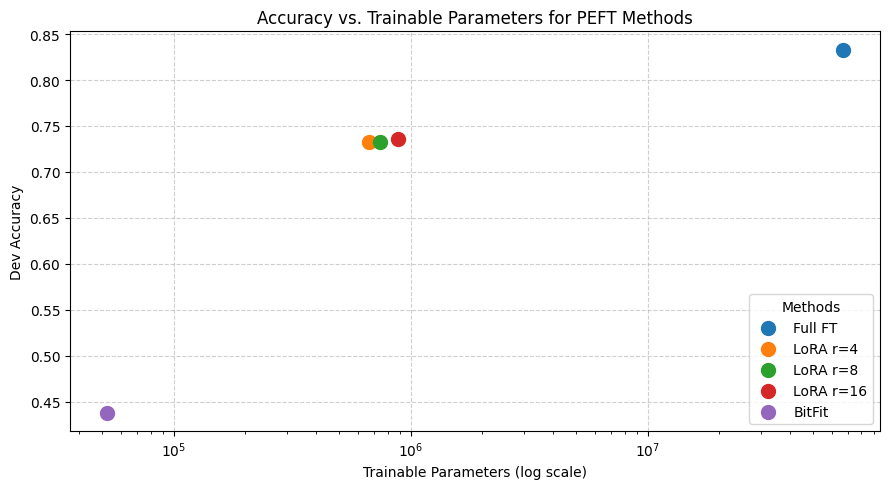

In [ ]:
import pandas as pd

peft_df = pd.DataFrame(peft_results)
peft_df.columns = ["Method", "Trainable Params", "% of Total", "Dev Acc", "Train Time (mins)"]
display(peft_df)

plt.figure(figsize=(9, 5))

for index, row in peft_df.iterrows():
    plt.scatter(row["Trainable Params"], row["Dev Acc"], label=row["Method"], s=100)

plt.legend(title="Methods", loc="lower right")
plt.xscale('log')
plt.xlabel('Trainable Parameters (log scale)')
plt.ylabel('Dev Accuracy')
plt.title('Accuracy vs. Trainable Parameters for PEFT Methods')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 3(c) Comparative Study

### 3(d) Possible Reasons Behind Observations

---
## Task 4: Cross-Dataset Generalisation

**Goal:** Evaluate zero-shot transfer to other NLI datasets.

### 4(a) Perform Task

In [ ]:
# Load saved baseline model
model_t4 = AutoModelForSequenceClassification.from_pretrained(
    str(MODEL_DIR / "task1_baseline"))
trainer_t4 = Trainer(model=model_t4,
    args=TrainingArguments(output_dir="./results/t4",
                           per_device_eval_batch_size=128,
                           report_to="none"),
    compute_metrics=compute_metrics)

eval_results = {}

# SNLI test
print("SNLI test...")
preds_s, labels_s = get_predictions(trainer_t4, test_tok)
eval_results["SNLI Test"] = accuracy_score(labels_s, preds_s)
print(f"  {eval_results['SNLI Test']:.4f}")

# MultiNLI
print("Loading MultiNLI...")
multinli = load_dataset("multi_nli")

for split_name, split_key in [("Matched", "validation_matched"),
                               ("Mismatched", "validation_mismatched")]:
    data = multinli[split_key]
    if MAX_TEST_EXAMPLES and len(data) > MAX_TEST_EXAMPLES:
        data = data.shuffle(seed=SEED).select(range(MAX_TEST_EXAMPLES))
    data = data.map(tokenize_fn, batched=True, num_proc=2)
    p, l = get_predictions(trainer_t4, data)
    eval_results[f"MultiNLI {split_name}"] = accuracy_score(l, p)
    print(f"  MultiNLI {split_name}: {eval_results[f'MultiNLI {split_name}']:.4f}")

# ANLI R1
print("Loading ANLI...")
anli = load_dataset("anli")
anli_r1 = anli["test_r1"].map(tokenize_fn, batched=True, num_proc=2)
preds_anli, labels_anli = get_predictions(trainer_t4, anli_r1)
eval_results["ANLI R1"] = accuracy_score(labels_anli, preds_anli)
print(f"  ANLI R1: {eval_results['ANLI R1']:.4f}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

SNLI test...


  0.8280
Loading MultiNLI...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/214M [00:00<?, ?B/s]

...

Generating train_r3 split:   0%|          | 0/100459 [00:00<?, ? examples/s]

Generating dev_r3 split:   0%|          | 0/1200 [00:00<?, ? examples/s]

Generating test_r3 split:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/1000 [00:00<?, ? examples/s]

  ANLI R1: 0.3150


### 4(b) Analysis and Plots

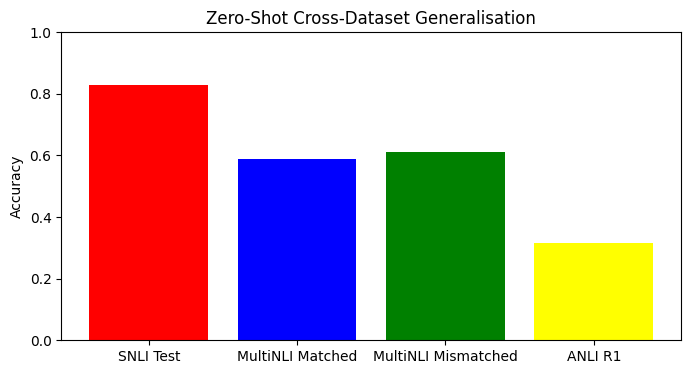

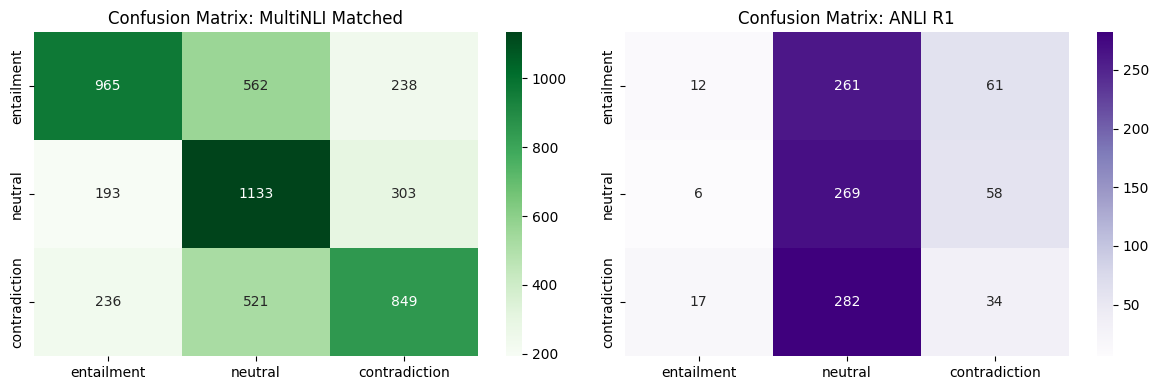

Example 1:
  Premise: Ernest Jones is a British jeweller and watchmaker. Established in 1949, its first store was opened in Oxford Street, London. Ernest Jones specialises in diamonds and watches, stocking brands such as Gucci and Emporio Armani. Ernest Jones is part of the Signet Jewelers group.
  Hypothesis: The first Ernest Jones store was opened on the continent of Europe.
  True Label: entailment | Predicted: neutral


Example 2:
  Premise: Old Trafford is a football stadium in Old Trafford, Greater Manchester, England, and the home of Manchester United. With a capacity of 75,643, it is the largest club football stadium in the United Kingdom, the second-largest football stadium, and the eleventh-largest in Europe. It is about 0.5 mi from Old Trafford Cricket Ground and the adjacent tram stop.
  Hypothesis: There are only 10 larger football stadiums in Europe.
  True Label: entailment | Predicted: contradiction


Example 3:
  Premise: Magnus is a Belgian joint dance project of Tom 

In [ ]:
# bar chart
datasets = list(eval_results.keys())
accuracies = list(eval_results.values())

plt.figure(figsize=(8, 4))
bars = plt.bar(datasets, accuracies, color=['red', 'blue', 'green', 'yellow'])
plt.ylabel('Accuracy')
plt.title('Zero-Shot Cross-Dataset Generalisation')
plt.ylim(0, 1)
plt.show()

# confusion matrix
data_m = multinli["validation_matched"]
if MAX_TEST_EXAMPLES and len(data_m) > MAX_TEST_EXAMPLES:
    data_m = data_m.shuffle(seed=SEED).select(range(MAX_TEST_EXAMPLES))
data_m_tok = data_m.map(tokenize_fn, batched=True, num_proc=2)
preds_m, labels_m = get_predictions(trainer_t4, data_m_tok)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# MultiNLI Matched
cm_m = confusion_matrix(labels_m, preds_m)
sns.heatmap(cm_m, annot=True, fmt='d', cmap='Greens', xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix: MultiNLI Matched')

# ANLI R1
cm_anli = confusion_matrix(labels_anli, preds_anli)
sns.heatmap(cm_anli, annot=True, fmt='d', cmap='Purples', xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix: ANLI R1')

plt.tight_layout()
plt.show()

# print 10 misclassified examples from ANLI R1
incorrect_indices = np.where(preds_anli != labels_anli)[0]
for i in range(min(10, len(incorrect_indices))):
    idx = incorrect_indices[i]
    example = anli["test_r1"][int(idx)]
    print(f"Example {i+1}:")
    print(f"  Premise: {example['premise']}")
    print(f"  Hypothesis: {example['hypothesis']}")
    print(f"  True Label: {LABEL_NAMES[labels_anli[idx]]} | Predicted: {LABEL_NAMES[preds_anli[idx]]}")
    print("\n")

### 4(c) Comparative Study

### 4(d) Possible Reasons Behind Observations

---
## Task 5: Data Efficiency Analysis

**Goal:** How much labelled data is needed for effective fine-tuning?

> Note: This task creates subsets relative to the **full** SNLI training set, not the subset used in earlier tasks.

### 5(a) Perform Task

In [ ]:
data_results = []
fractions = [0.01, 0.10, 0.25, 0.50, 1.0]
seeds = [42]

full_train = dataset["train"]

for frac in fractions:
  for seed in seeds:
    print(f"\n--- Training on {frac*100}% of Data ---")

    n = int(len(full_train) * frac)
    subset = full_train.shuffle(seed=seed).select(range(n))

    subset_tok = subset.map(tokenize_fn, batched=True, num_proc=2)
    model = get_fresh_model()
    args = make_training_args(f"./results/t5_data_{frac}")

    trainer = Trainer(model=model, args=args, train_dataset=subset_tok, eval_dataset=val_tok, compute_metrics=compute_metrics)
    trainer.train()

    acc = trainer.evaluate()["eval_accuracy"]
    data_results.append({"Fraction": frac, "Dev Accuracy": acc})
    print(f"Accuracy for {frac*100}%: {acc:.4f}")


--- Training on 1.0% of Data ---


Map (num_proc=2):   0%|          | 0/5493 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Map (num_proc=2):   0%|          | 0/549367 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.385012,0.319809,0.882400
2,0.296231,0.284727,0.896200
3,0.253070,0.292684,0.899200


Accuracy for 100.0%: 0.8992


### 5(b) Analysis and Plots

,Fraction,Dev Accuracy
0,0.01,0.7568
1,0.10,0.8332
2,0.25,0.8606
3,0.50,0.8820
4,1.00,0.8992


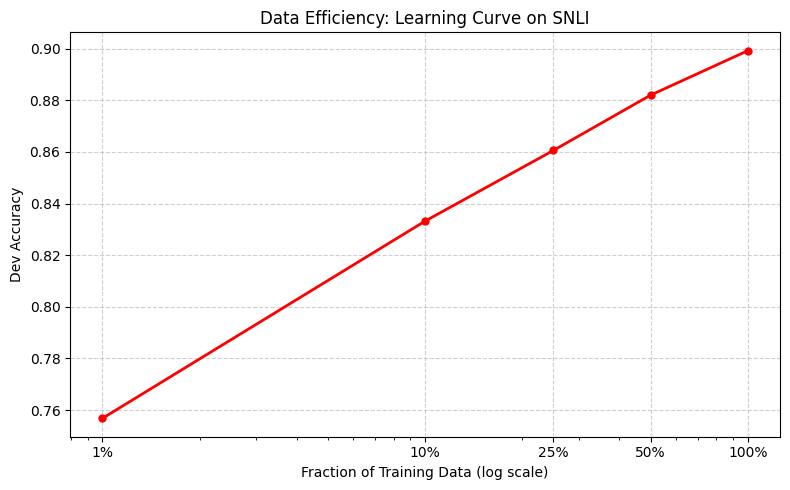

In [ ]:
import pandas as pd
data_df = pd.DataFrame(data_results)
display(data_df)

plt.figure(figsize=(8, 5))
plt.plot(data_df["Fraction"], data_df["Dev Accuracy"], marker='o', color='red', linewidth=2, markersize=5)

plt.xscale('log')
plt.xticks(fractions, [f"{int(f*100)}%" for f in fractions])
plt.xlabel('Fraction of Training Data (log scale)')
plt.ylabel('Dev Accuracy')
plt.title('Data Efficiency: Learning Curve on SNLI')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 5(c) Comparative Study

### 5(d) Possible Reasons Behind Observations